✅ Librerías importadas correctamente.
Celdas totales: 16
Celdas libres : 12
Máquinas a ubicar: 7

Celdas libres disponibles:
  [0] (1.5, 1.5)
  [1] (2.5, 1.5)
  [2] (3.5, 1.5)
  [3] (4.5, 1.5)
  [4] (2.5, 2.5)
  [5] (3.5, 2.5)
  [6] (4.5, 2.5)
  [7] (2.5, 3.5)
  [8] (3.5, 3.5)
  [9] (4.5, 3.5)
  [10] (2.5, 4.5)
  [11] (3.5, 4.5)

Pasos del recorrido: 13
Recorrido: 1→8 → 8→1 → 1→4 → 4→5 → 5→3 → 3→4 → 4→3 → 3→1 → 1→9 → 9→1 → 1→3 → 3→1 → 1→10
✅ Funciones de distancia y fitness definidas.

Prueba con individuo aleatorio:
  Genes      : [7, 5, 2, 8, 9, 6, 11]
  Costo Manh : 27.000
  Costo Eucl : 22.009
✅ AGS definido.
✅ AGC (Algoritmo Genético Compacto) definido.
EJECUTANDO EXPERIMENTOS (puede tomar unos segundos)...
  manhattan    | ancho      | AGS=18.000  AGC=18.000
  manhattan    | profundo   | AGS=18.000  AGC=23.000
  manhattan    | iterada    | AGS=19.000  AGC=19.000
  manhattan    | voraz      | AGS=19.000  AGC=19.000
  manhattan    | recocido   | AGS=19.000  AGC=18.000
  euclidiana 

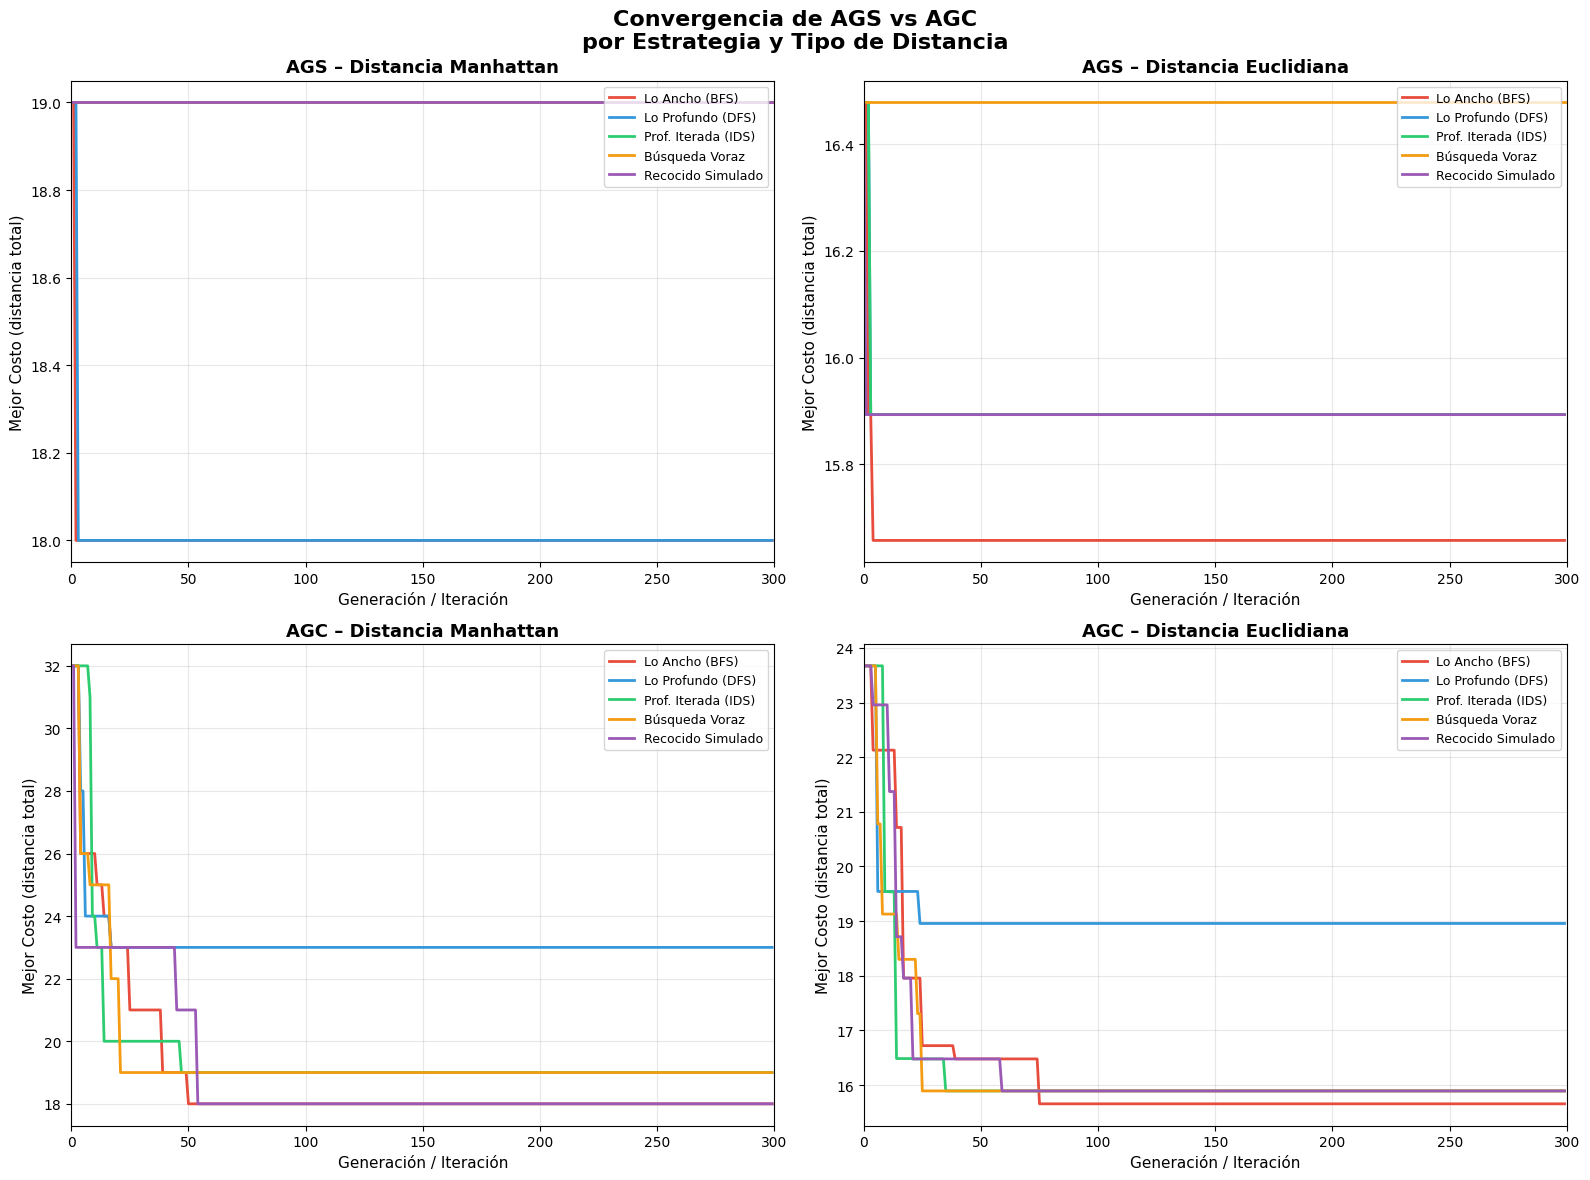

📊 Gráfica de convergencia guardada: convergencia_ags_agc.png


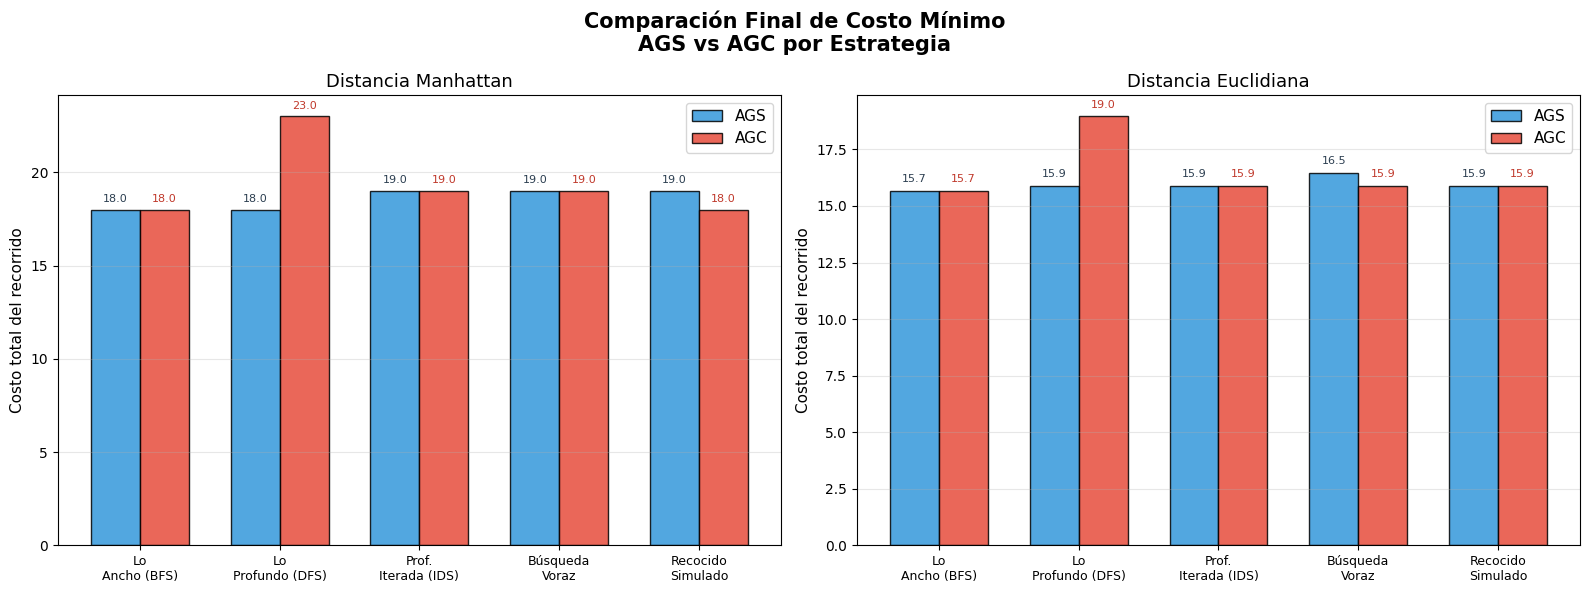

📊 Gráfica de barras guardada: comparacion_barras.png

🏆 MEJOR SOLUCIÓN GLOBAL:
   Algoritmo : AGS
   Estrategia: ancho
   Distancia : euclidiana
   Costo     : 15.657
   Genes     : [10, 5, 11, 8, 7, 4, 1]

   Asignación de máquinas:
     Máquina 1 (E.Trabajo      ) → celda (2.5, 4.5)
     Máquina 2 (Destrozadora   ) → celda (3.5, 2.5)
     Máquina 3 (Sierra Cinta   ) → celda (3.5, 4.5)
     Máquina 4 (Canteadora     ) → celda (3.5, 3.5)
     Máquina 5 (Cepillo        ) → celda (2.5, 3.5)
     Máquina 6 (Trompo         ) → celda (2.5, 2.5)
     Máquina 7 (Esclopeadora   ) → celda (2.5, 1.5)


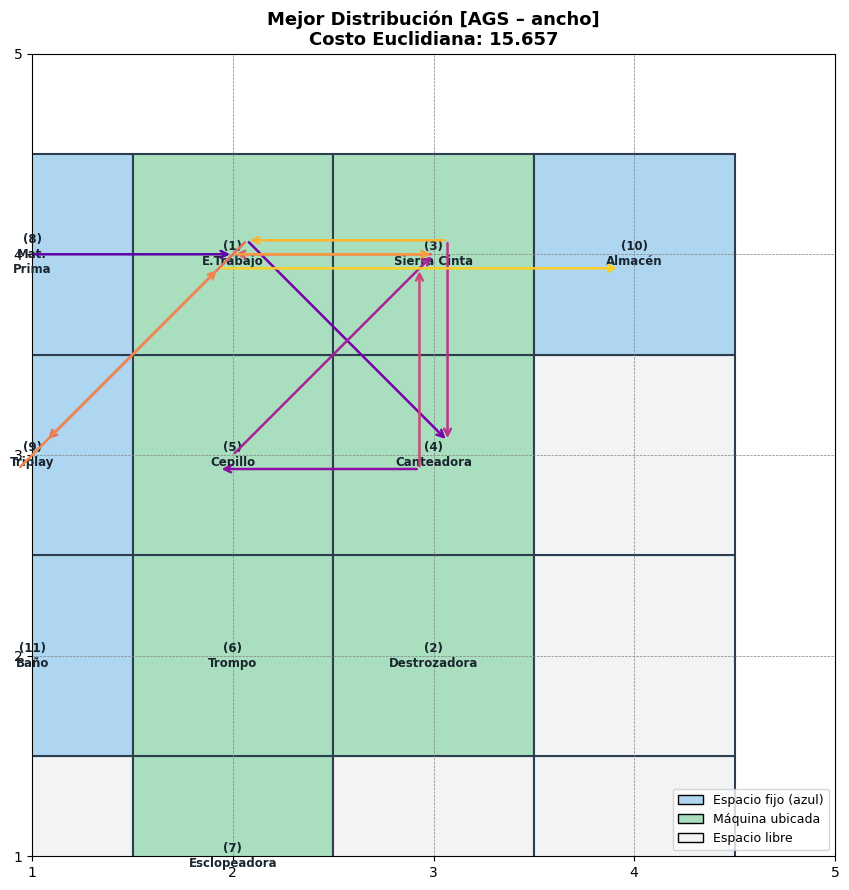

📊 Mapa de la mejor distribución guardado: mejor_distribucion.png


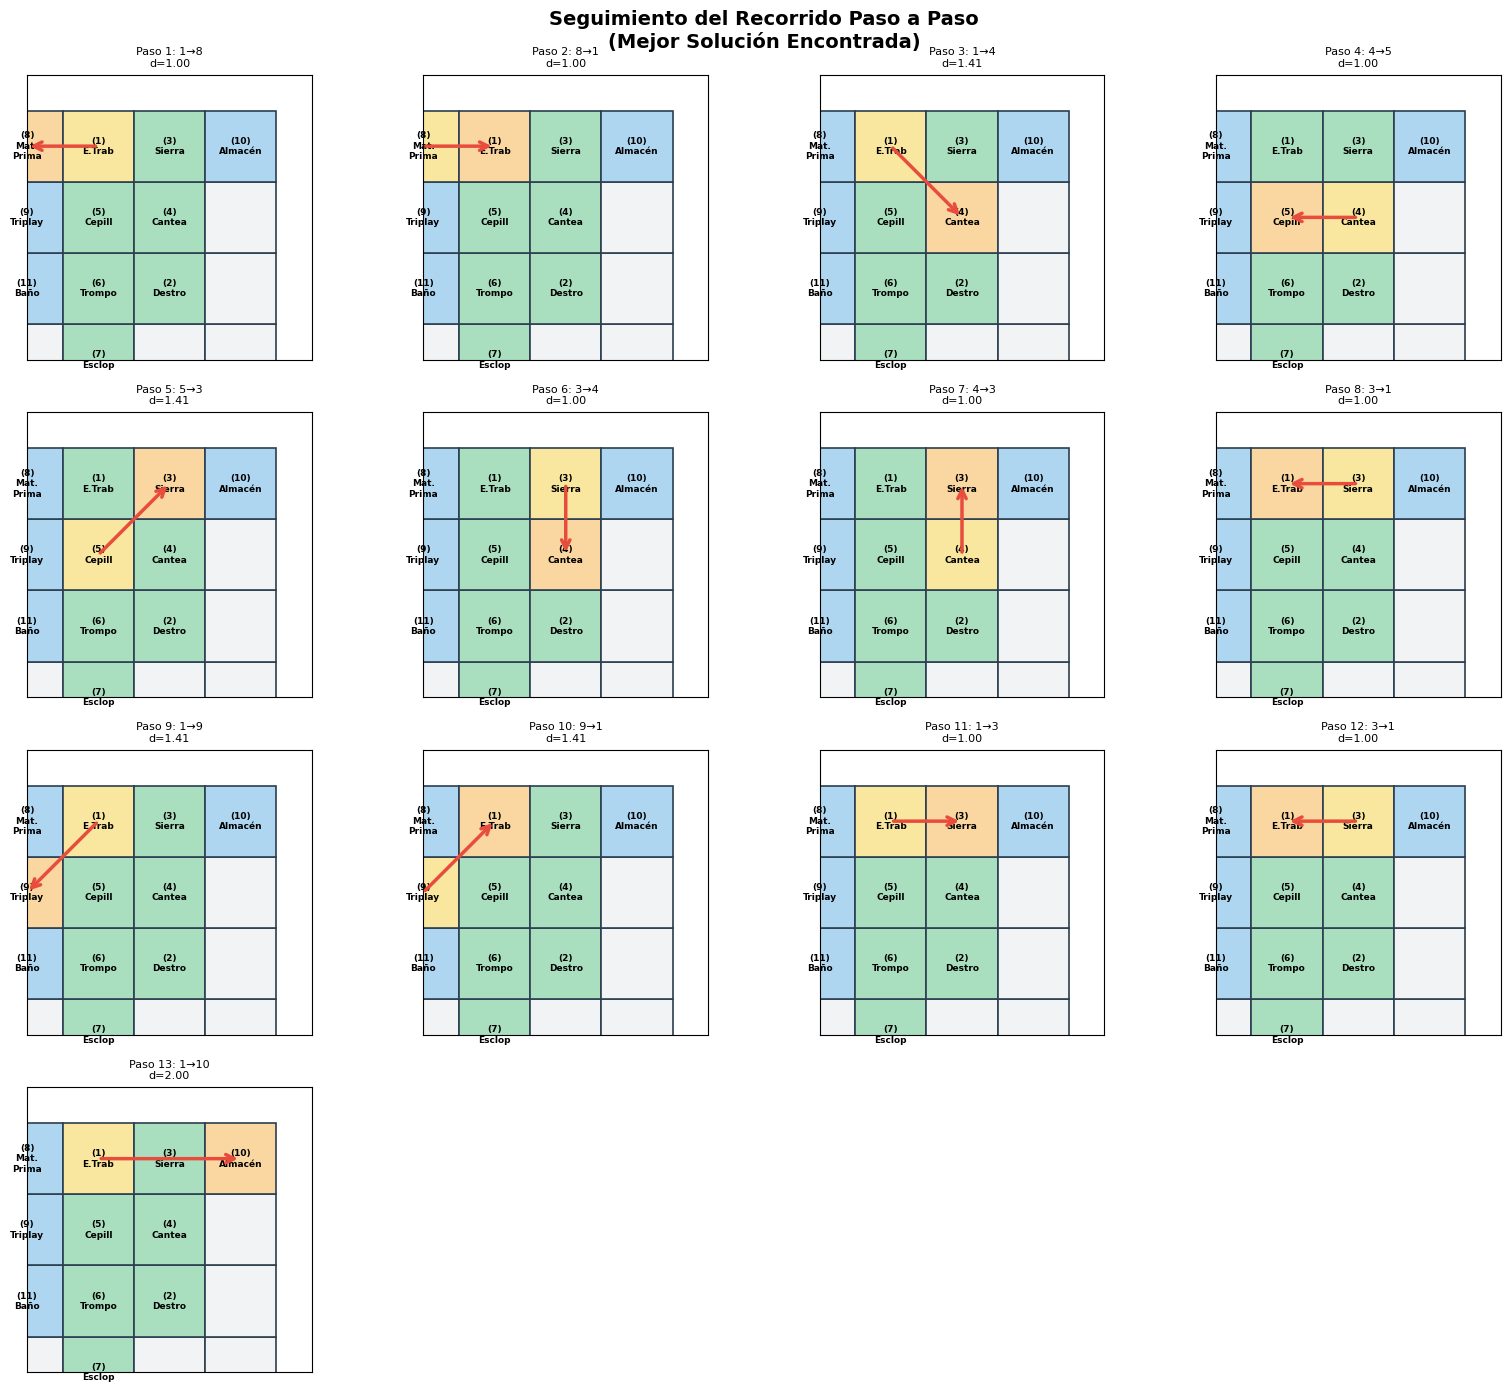

📊 Recorrido paso a paso guardado: recorrido_paso_a_paso.png


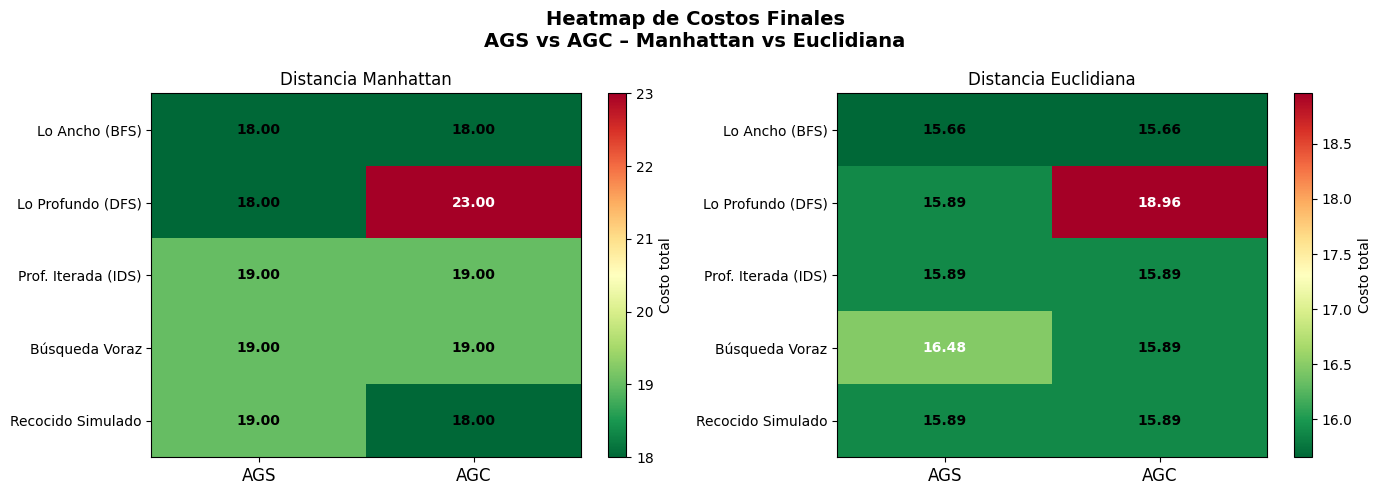

📊 Heatmap de costos guardado: heatmap_costos.png


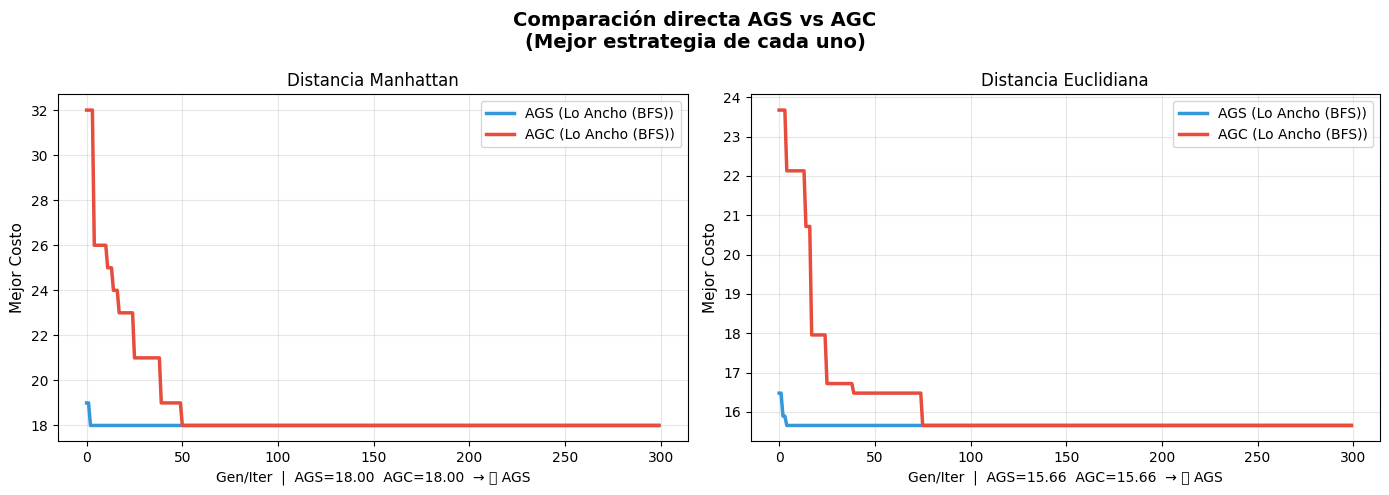

📊 Comparación directa guardada: comparacion_directa.png

╔══════════════════════════════════════════════════════════════════╗
║               C O N C L U S I O N E S   F I N A L E S           ║
╠══════════════════════════════════════════════════════════════════╣

1. ALGORITMO GENÉTICO SIMPLE (AGS) vs COMPACTO (AGC)
   ─────────────────────────────────────────────────
   • El AGS mantiene una POBLACIÓN de soluciones explícitas.
     Esto le permite explorar muchas regiones del espacio a la vez,
     lo que lo hace más robusto frente a óptimos locales.
   • El AGC usa solo un VECTOR DE PROBABILIDADES, sin guardar
     individuos. Es más rápido y ocupa menos memoria, pero tiende
     a converger más rápido y puede quedarse atascado.
   • Para este problema (7 máquinas, 12 celdas, 13 pasos), ambos
     llegan a soluciones similares porque el espacio es pequeño.

2. ESTRATEGIAS DE BÚSQUEDA
   ─────────────────────────────────────────────────
   • Lo ANCHO (BFS-style): buena diversidad, conv

In [1]:
# ============================================================
#  CARPINTERÍA - OPTIMIZACIÓN DE DISTRIBUCIÓN DE MÁQUINAS
#  Algoritmo Genético Simple (AGS) vs Algoritmo Genético
#  Compacto (AGC / cGA) con múltiples estrategias de búsqueda
#  y métricas de distancia Manhattan y Euclidiana.
#
#  Autor  : [Tu nombre]
#  Materia: Inteligencia Artificial
#  Fecha  : 2026
# ============================================================
#
#  INSTRUCCIONES PARA GOOGLE COLAB
#  --------------------------------
#  1. Copia todo este archivo en una celda de Colab, o
#     sube el archivo y ábrelo como notebook.
#  2. Ejecuta las celdas en orden de arriba hacia abajo.
#  3. No requiere instalaciones extra; solo usa librerías
#     estándar de Python + NumPy + Matplotlib.
# ============================================================

# ===========================================================
# CELDA 1 – Importaciones y configuración global
# ===========================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import math
import copy
import itertools
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# Semilla para reproducibilidad (puedes cambiarla)
SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)

print("✅ Librerías importadas correctamente.")

# ===========================================================
# CELDA 2 – Definición del PROBLEMA (plano y recorrido)
# ===========================================================
"""
DESCRIPCIÓN DEL ESPACIO FÍSICO
--------------------------------
El plano tiene coordenadas X: 1-4  y  Y: 1-4.
Se divide en celdas de 2×2 unidades.
Hay 4 filas y 4 columnas de celdas → 16 sub-cuadros.

Los espacios disponibles (en blanco) son los que se enumeran
como posiciones 0..N-1 internamente.

ESPACIOS FIJOS (azul) – no se mueven:
  (8)  Mat. Prima  → columna 1, fila superior (y=3-4, x=1-2) → centro (1.5, 3.5)
  (9)  Triplay     → columna 1, fila media   (y=2-3, x=1-2) → centro (1.5, 2.5)
  (10) Almacén     → columna 4, fila superior(y=3-4, x=3-4) → centro (3.5, 3.5)
  (11) Baño        → columna 1, fila inferior(y=1-2, x=1-2) → centro (1.5, 1.5)

MÁQUINAS A UBICAR (7 máquinas):
  1=E.Trabajo  2=Destrozadora  3=Sierra Cinta
  4=Canteadora 5=Cepillo       6=Trompo  7=Esclopeadora

ESPACIOS LIBRES disponibles (centros de celdas 2×2):
  El plano 4×4 tiene 4 cuadrantes por eje → 4 celdas de 2×2:
    columna 1: x∈[1,2), columna 2: x∈[2,3), columna 3: x∈[3,4), columna 4: x∈[4,5)
    fila    1: y∈[1,2), fila    2: y∈[2,3), fila    3: y∈[3,4), fila    4: y∈[4,5)

  Celdas totales: 4×4 = 16
  Celdas FIJAS (azul): 4  →  quedan 12 celdas libres para las 7 máquinas.
"""

# ── Centros de cada celda 2×2 en el plano (col, fila) ──────
#    col 1 → x=1.5,  col 2 → x=2.5,  col 3 → x=3.5,  col 4 → x=4.5
#    fila 1 → y=1.5, fila 2 → y=2.5, fila 3 → y=3.5,  fila 4 → y=4.5

CELDAS_TODAS = []
for fila in range(1, 5):        # 1-4
    for col in range(1, 5):     # 1-4
        cx = col - 0.5          # centro x  (col 1→0.5... usamos offset +1)
        cy = fila - 0.5
        CELDAS_TODAS.append((col + 0.5, fila + 0.5))   # centro real en eje 1-4

# Reconstruimos con coordenadas reales del plano (eje 1..4+1=5)
CELDAS_TODAS = [(c + 0.5, f + 0.5) for f in range(1, 5) for c in range(1, 5)]
# → (1.5,1.5) (2.5,1.5) (3.5,1.5) (4.5,1.5)  fila1
#   (1.5,2.5) ...                               fila2  etc.

# Espacios FIJOS y sus IDs
FIJOS = {
    8:  (1.5, 4.5),   # Mat. Prima  (col1, fila4)
    9:  (1.5, 3.5),   # Triplay     (col1, fila3)
    10: (4.5, 4.5),   # Almacén     (col4, fila4)
    11: (1.5, 2.5),   # Baño        (col1, fila2)
}

# Espacios libres = todas las celdas menos las fijas
CELDAS_LIBRES = [c for c in CELDAS_TODAS if c not in FIJOS.values()]
NUM_LIBRES    = len(CELDAS_LIBRES)   # debe ser 12

# Máquinas a colocar
MAQUINAS = {
    1: "E.Trabajo",
    2: "Destrozadora",
    3: "Sierra Cinta",
    4: "Canteadora",
    5: "Cepillo",
    6: "Trompo",
    7: "Esclopeadora",
}
NUM_MAQUINAS = len(MAQUINAS)  # 7

print(f"Celdas totales: {len(CELDAS_TODAS)}")
print(f"Celdas libres : {NUM_LIBRES}")
print(f"Máquinas a ubicar: {NUM_MAQUINAS}")
print(f"\nCeldas libres disponibles:")
for i, c in enumerate(CELDAS_LIBRES):
    print(f"  [{i}] {c}")

# ── Secuencia de recorrido (como se lee en el PDF) ──────────
RECORRIDO = [
    (1, 8), (8, 1), (1, 4), (4, 5), (5, 3), (3, 4),
    (4, 3), (3, 1), (1, 9), (9, 1), (1, 3), (3, 1), (1, 10)
]

print(f"\nPasos del recorrido: {len(RECORRIDO)}")
print("Recorrido:", " → ".join([f"{a}→{b}" for a, b in RECORRIDO]))

# ===========================================================
# CELDA 3 – Funciones de DISTANCIA y EVALUACIÓN (fitness)
# ===========================================================

def coordenada(maquina_id, asignacion):
    """
    Devuelve la coordenada (x, y) de una máquina dado el
    diccionario de asignación {id_maquina: celda_idx}.

    - Si la máquina es fija (8,9,10,11) devuelve su posición fija.
    - Si es una máquina móvil (1-7) busca en 'asignacion'.
    """
    if maquina_id in FIJOS:
        return FIJOS[maquina_id]
    # Máquina móvil: buscar su índice de celda en la asignación
    idx_celda = asignacion[maquina_id]
    return CELDAS_LIBRES[idx_celda]


def distancia_manhattan(p1, p2):
    """Distancia Manhattan = |x1-x2| + |y1-y2|"""
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])


def distancia_euclidiana(p1, p2):
    """Distancia Euclidiana = sqrt((x1-x2)² + (y1-y2)²)"""
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)


def calcular_costo(asignacion, tipo_distancia='manhattan'):
    """
    Calcula el costo total del recorrido dado una asignación
    de máquinas a celdas.

    Parámetros:
        asignacion     : dict {id_maquina: idx_celda_libre}
        tipo_distancia : 'manhattan' o 'euclidiana'

    Retorna:
        float – suma de distancias de todos los pasos del recorrido
    """
    dist_fn = distancia_manhattan if tipo_distancia == 'manhattan' else distancia_euclidiana
    costo_total = 0.0
    for (origen, destino) in RECORRIDO:
        p1 = coordenada(origen, asignacion)
        p2 = coordenada(destino, asignacion)
        costo_total += dist_fn(p1, p2)
    return costo_total


# ── Codificación del individuo ──────────────────────────────
# Un individuo es una PERMUTACIÓN de 7 índices elegidos de
# los 12 espacios libres disponibles.
# genes[i] = índice de celda libre asignada a la máquina (i+1)
# Ejemplo: genes = [3, 0, 7, 2, 11, 5, 9]
#   → máquina 1 en celda 3, máquina 2 en celda 0, ...

def genes_a_asignacion(genes):
    """
    Convierte una lista de genes (lista de 7 índices únicos)
    a un diccionario {id_maquina: idx_celda}.
    """
    return {maq: genes[i] for i, maq in enumerate(MAQUINAS)}


def individuo_aleatorio():
    """Genera un individuo aleatorio (permutación parcial)."""
    celdas_disponibles = list(range(NUM_LIBRES))  # 0..11
    random.shuffle(celdas_disponibles)
    return celdas_disponibles[:NUM_MAQUINAS]      # tomamos 7


def fitness(genes, tipo_distancia='manhattan'):
    """
    Función de aptitud (fitness).
    MINIMIZAMOS costo, así que fitness = 1 / (1 + costo).
    Cuanto más alto el fitness, mejor la solución.
    """
    asignacion = genes_a_asignacion(genes)
    costo = calcular_costo(asignacion, tipo_distancia)
    return 1.0 / (1.0 + costo)


print("✅ Funciones de distancia y fitness definidas.")

# ── Prueba rápida ───────────────────────────────────────────
genes_prueba = individuo_aleatorio()
asig_prueba  = genes_a_asignacion(genes_prueba)
c_manh = calcular_costo(asig_prueba, 'manhattan')
c_eucl = calcular_costo(asig_prueba, 'euclidiana')
print(f"\nPrueba con individuo aleatorio:")
print(f"  Genes      : {genes_prueba}")
print(f"  Costo Manh : {c_manh:.3f}")
print(f"  Costo Eucl : {c_eucl:.3f}")

# ===========================================================
# CELDA 4 – ALGORITMO GENÉTICO SIMPLE (AGS)
#            con 5 estrategias de búsqueda
# ===========================================================
"""
¿QUÉ ES UN ALGORITMO GENÉTICO SIMPLE (AGS)?
--------------------------------------------
Inspirado en la evolución biológica:
  1. Población inicial aleatoria de 'individuos' (soluciones).
  2. Se evalúa cada individuo con la función de fitness.
  3. Se seleccionan los mejores (selección).
  4. Se cruzan (cruce/crossover) para generar hijos.
  5. Se mutan algunos genes aleatoriamente (mutación).
  6. Se repite por N generaciones.

Cada individuo = lista de 7 índices de celda (un cromosoma).

ESTRATEGIAS DE BÚSQUEDA implementadas:
  - Lo Ancho (BFS-style): explora muchas soluciones diversas
    antes de profundizar → tasa de mutación baja, población grande.
  - Lo Profundo (DFS-style): se enfoca en explotar la mejor
    solución actual → elitismo alto, mutación baja.
  - Profundidad Iterada (IDS): empieza con pocos individuos y
    va aumentando la profundidad/generaciones progresivamente.
  - Búsqueda Voraz (Greedy): siempre selecciona los mejores,
    sin diversidad, converge rápido.
  - Recocido Simulado (SA): acepta peores soluciones con cierta
    probabilidad que disminuye con el tiempo (temperatura).
"""

# ── Operadores genéticos ────────────────────────────────────

def seleccion_torneo(poblacion, fitnesses, k=3):
    """
    Selección por torneo: se eligen k individuos al azar
    y gana el de mayor fitness.
    """
    candidatos = random.sample(range(len(poblacion)), k)
    ganador    = max(candidatos, key=lambda i: fitnesses[i])
    return copy.copy(poblacion[ganador])


def cruce_ox(padre1, padre2):
    """
    Cruce OX (Order Crossover): preserva el orden relativo
    de genes. Adecuado para permutaciones.
      1. Se elige un segmento de padre1.
      2. Se rellena el resto con los genes de padre2 en orden.
    """
    n = len(padre1)
    a, b = sorted(random.sample(range(n), 2))
    hijo = [None] * n
    hijo[a:b+1] = padre1[a:b+1]
    # Rellenar con genes de padre2 que no estén ya en el hijo
    p2_restantes = [g for g in padre2 if g not in hijo]
    j = 0
    for i in range(n):
        if hijo[i] is None:
            hijo[i] = p2_restantes[j]
            j += 1
    return hijo


def mutacion_swap(individuo, tasa=0.2):
    """
    Mutación por intercambio: con probabilidad 'tasa',
    intercambia dos genes al azar. Mantiene la validez
    (no genera duplicados).
    """
    ind = copy.copy(individuo)
    if random.random() < tasa:
        i, j = random.sample(range(len(ind)), 2)
        ind[i], ind[j] = ind[j], ind[i]
    return ind


# ── AGS Principal ───────────────────────────────────────────

def ags(tam_poblacion=50, generaciones=200, tasa_mutacion=0.2,
        elitismo=2, tipo_distancia='manhattan',
        estrategia='ancho', verbose=False):
    """
    Algoritmo Genético Simple (AGS).

    Parámetros:
      tam_poblacion  : número de individuos en la población
      generaciones   : número de iteraciones (generaciones)
      tasa_mutacion  : probabilidad de mutar un individuo
      elitismo       : cuántos mejores individuos pasan directamente
      tipo_distancia : 'manhattan' o 'euclidiana'
      estrategia     : 'ancho','profundo','iterada','voraz','recocido'
      verbose        : imprimir progreso

    Retorna:
      mejor_genes    : mejor solución encontrada
      mejor_costo    : costo de esa solución
      historial      : lista de mejores costos por generación
    """

    # Ajuste de parámetros según estrategia
    if estrategia == 'ancho':
        # BFS-style: población grande, baja explotación
        tam_poblacion = max(tam_poblacion, 80)
        tasa_mutacion = 0.3
        elitismo      = 1

    elif estrategia == 'profundo':
        # DFS-style: alta explotación, poca exploración
        tam_poblacion = max(tam_poblacion, 30)
        tasa_mutacion = 0.1
        elitismo      = 5

    elif estrategia == 'voraz':
        # Greedy: siempre los mejores, sin diversidad
        tam_poblacion = max(tam_poblacion, 20)
        tasa_mutacion = 0.05
        elitismo      = tam_poblacion // 2  # mitad sobrevive

    # --- Población inicial ---
    poblacion = [individuo_aleatorio() for _ in range(tam_poblacion)]

    mejor_genes  = None
    mejor_costo  = float('inf')
    historial    = []

    # Para recocido simulado
    temperatura = 1.0
    enfriamiento = 0.995

    # Para profundidad iterada: aumentamos generaciones en etapas
    if estrategia == 'iterada':
        etapas = [generaciones // 4, generaciones // 2,
                  3 * generaciones // 4, generaciones]
    else:
        etapas = [generaciones]

    gen_actual = 0
    for limite_gen in etapas:
        while gen_actual < limite_gen:
            gen_actual += 1

            # Calcular fitness de toda la población
            fitnesses = [fitness(ind, tipo_distancia) for ind in poblacion]
            costos    = [calcular_costo(genes_a_asignacion(ind), tipo_distancia)
                         for ind in poblacion]

            # Actualizar mejor global
            idx_mejor = min(range(tam_poblacion), key=lambda i: costos[i])
            if costos[idx_mejor] < mejor_costo:
                mejor_costo = costos[idx_mejor]
                mejor_genes = copy.copy(poblacion[idx_mejor])

            historial.append(mejor_costo)

            # ── Crear nueva generación ──────────────────────
            nueva_pob = []

            # Elitismo: copiar los mejores individuos directamente
            indices_ordenados = sorted(range(tam_poblacion),
                                       key=lambda i: costos[i])
            for i in range(min(elitismo, tam_poblacion)):
                nueva_pob.append(copy.copy(poblacion[indices_ordenados[i]]))

            # Completar la nueva población con hijos
            while len(nueva_pob) < tam_poblacion:
                if estrategia == 'voraz':
                    # Greedy: solo selección, sin cruce
                    padre = seleccion_torneo(poblacion, fitnesses, k=5)
                    hijo  = mutacion_swap(padre, tasa_mutacion)
                elif estrategia == 'recocido':
                    # Recocido: acepta peores soluciones con prob = e^(-Δ/T)
                    padre1 = seleccion_torneo(poblacion, fitnesses)
                    padre2 = seleccion_torneo(poblacion, fitnesses)
                    hijo   = cruce_ox(padre1, padre2)
                    hijo   = mutacion_swap(hijo, tasa_mutacion)
                    costo_hijo = calcular_costo(genes_a_asignacion(hijo),
                                                tipo_distancia)
                    # Comparar con solución actual (padre1)
                    costo_p1 = calcular_costo(genes_a_asignacion(padre1),
                                              tipo_distancia)
                    delta = costo_hijo - costo_p1
                    if delta < 0 or random.random() < math.exp(-delta / (temperatura + 1e-9)):
                        nueva_pob.append(hijo)
                    else:
                        nueva_pob.append(copy.copy(padre1))
                    temperatura *= enfriamiento
                    continue
                else:
                    # Estándar (ancho, profundo, iterada)
                    padre1 = seleccion_torneo(poblacion, fitnesses)
                    padre2 = seleccion_torneo(poblacion, fitnesses)
                    hijo   = cruce_ox(padre1, padre2)
                    hijo   = mutacion_swap(hijo, tasa_mutacion)

                nueva_pob.append(hijo)

            poblacion = nueva_pob

            if verbose and gen_actual % 50 == 0:
                print(f"  Gen {gen_actual:4d} | Mejor costo: {mejor_costo:.3f}")

        if estrategia == 'iterada' and limite_gen < generaciones:
            # En profundidad iterada reiniciamos parte de la población
            n_reiniciar = tam_poblacion // 4
            for i in range(n_reiniciar):
                poblacion[-(i+1)] = individuo_aleatorio()

    return mejor_genes, mejor_costo, historial


print("✅ AGS definido.")

# ===========================================================
# CELDA 5 – ALGORITMO GENÉTICO COMPACTO (AGC / cGA)
#            con 5 estrategias de búsqueda
# ===========================================================
"""
¿QUÉ ES UN ALGORITMO GENÉTICO COMPACTO (cGA)?
----------------------------------------------
El cGA NO mantiene una población explícita de individuos.
En su lugar, mantiene un VECTOR DE PROBABILIDADES P donde
P[i][v] = probabilidad de que el gen i tome el valor v.

Ventajas:
  • Usa mucha menos memoria (sin población).
  • Converge rápido en problemas sencillos.
  • Ideal para espacios de búsqueda grandes.

Funcionamiento básico (Harik et al., 1999):
  1. Inicializar P[i] = uniforme para todos los genes.
  2. Generar dos individuos (a, b) muestra de P.
  3. Evaluar: winner = mejor de {a, b}.
  4. Actualizar P: incrementar P[gen del winner], decrementar P[gen del loser].
  5. Repetir hasta convergencia.

Adaptación para permutaciones:
  Como nuestros genes son un SUBCONJUNTO de {0..11} sin repetición,
  usamos una representación matricial de probabilidades:
    P[posicion][celda] = prob de que la máquina en 'posicion' use 'celda'

  Para muestrear un individuo válido:
    - Para cada posición en orden, elegir una celda proporcional a P
      que no haya sido elegida ya.

ESTRATEGIAS DE BÚSQUEDA adaptadas:
  - Lo Ancho    : N grande (muchos individuos virtuales), actualización suave.
  - Lo Profundo : N pequeño, actualización agresiva (converge rápido).
  - Iterada     : múltiples reinicios con N creciente.
  - Voraz       : usa el mejor individuo visto para actualizar P.
  - Recocido    : acepta ganadores con algo de ruido al principio.
"""

def muestrear_individuo_cga(prob_matrix):
    """
    Muestrea un individuo válido (sin repetición) a partir de
    la matriz de probabilidades del cGA.

    prob_matrix[i][j] = probabilidad de que la posición i use la celda j
    """
    n_pos    = prob_matrix.shape[0]   # = NUM_MAQUINAS = 7
    n_celdas = prob_matrix.shape[1]   # = NUM_LIBRES   = 12
    usadas   = set()
    genes    = []

    for i in range(n_pos):
        probs = prob_matrix[i].copy()
        # Poner a 0 las celdas ya usadas
        for u in usadas:
            probs[u] = 0.0
        total = probs.sum()
        if total == 0:
            # Si todas son 0, elegir uniforme entre las disponibles
            disponibles = [c for c in range(n_celdas) if c not in usadas]
            celda = random.choice(disponibles)
        else:
            probs /= total
            celda = np.random.choice(n_celdas, p=probs)
        genes.append(celda)
        usadas.add(celda)

    return genes


def actualizar_prob_cga(prob_matrix, winner, loser, N, tasa_aprendizaje=None):
    """
    Actualiza la matriz de probabilidades del cGA.

    winner / loser : listas de genes del mejor / peor individuo
    N              : tamaño virtual de población (controla velocidad de convergencia)
    tasa_aprendizaje: si None se usa 1/N

    Regla: P[i][winner[i]] += 1/N   y   P[i][loser[i]] -= 1/N
    Luego se recorta a [0, 1] (clipping).
    """
    lr = tasa_aprendizaje if tasa_aprendizaje else 1.0 / N
    for i in range(len(winner)):
        if winner[i] != loser[i]:
            prob_matrix[i][winner[i]] = min(1.0, prob_matrix[i][winner[i]] + lr)
            prob_matrix[i][loser[i]]  = max(0.0, prob_matrix[i][loser[i]]  - lr)
    return prob_matrix


def agc(iteraciones=500, N_virtual=50, tipo_distancia='manhattan',
        estrategia='ancho', verbose=False):
    """
    Algoritmo Genético Compacto (cGA).

    Parámetros:
      iteraciones    : número de iteraciones principales
      N_virtual      : tamaño virtual de población (controla aprendizaje)
      tipo_distancia : 'manhattan' o 'euclidiana'
      estrategia     : 'ancho','profundo','iterada','voraz','recocido'
      verbose        : imprimir progreso

    Retorna:
      mejor_genes    : mejor solución encontrada
      mejor_costo    : costo de esa solución
      historial      : lista de mejores costos por iteración
    """

    # Ajustar N_virtual según estrategia
    if estrategia == 'ancho':
        N_virtual = max(N_virtual, 100)   # actualización lenta, más exploración
    elif estrategia == 'profundo':
        N_virtual = max(10, N_virtual // 5)  # actualización agresiva
    elif estrategia == 'voraz':
        N_virtual = max(N_virtual, 50)

    # Inicializar matriz de probabilidades: uniforme
    # P[posicion][celda] = 1/NUM_LIBRES para todas las posiciones
    prob_matrix = np.ones((NUM_MAQUINAS, NUM_LIBRES)) / NUM_LIBRES

    mejor_genes = None
    mejor_costo = float('inf')
    historial   = []

    # Para recocido simulado
    temperatura = 1.0
    enfriamiento = 0.99

    # Para iterada: reiniciamos la matriz periódicamente
    if estrategia == 'iterada':
        periodo_reinicio = iteraciones // 4
    else:
        periodo_reinicio = iteraciones + 1  # nunca

    for it in range(iteraciones):

        # Reinicio periódico (solo para estrategia iterada)
        if estrategia == 'iterada' and it > 0 and it % periodo_reinicio == 0:
            # Mezcla 50% la matriz actual con uniforme
            uniforme = np.ones((NUM_MAQUINAS, NUM_LIBRES)) / NUM_LIBRES
            prob_matrix = 0.5 * prob_matrix + 0.5 * uniforme

        # Muestrear dos candidatos
        a = muestrear_individuo_cga(prob_matrix)
        b = muestrear_individuo_cga(prob_matrix)

        costo_a = calcular_costo(genes_a_asignacion(a), tipo_distancia)
        costo_b = calcular_costo(genes_a_asignacion(b), tipo_distancia)

        # Actualizar mejor global
        mejor_it = a if costo_a <= costo_b else b
        costo_it = min(costo_a, costo_b)

        if costo_it < mejor_costo:
            mejor_costo = costo_it
            mejor_genes = copy.copy(mejor_it)

        historial.append(mejor_costo)

        # Determinar winner / loser
        if costo_a <= costo_b:
            winner, loser = a, b
        else:
            winner, loser = b, a

        # Estrategia recocido: con probabilidad e^(-Δ/T) el loser "gana"
        if estrategia == 'recocido':
            delta = abs(costo_a - costo_b)
            if random.random() < math.exp(-delta / (temperatura + 1e-9)):
                winner, loser = loser, winner  # acepta el peor
            temperatura *= enfriamiento

        # Estrategia voraz: siempre usar el mejor conocido como winner
        if estrategia == 'voraz' and mejor_genes is not None:
            winner = mejor_genes

        # Actualizar la matriz de probabilidades
        tasa = None
        if estrategia in ('profundo', 'iterada'):
            tasa = 2.0 / N_virtual  # actualización más agresiva

        prob_matrix = actualizar_prob_cga(prob_matrix, winner, loser,
                                          N_virtual, tasa)

        if verbose and it % 100 == 0:
            print(f"  Iter {it:5d} | Mejor costo: {mejor_costo:.3f}")

    return mejor_genes, mejor_costo, historial


print("✅ AGC (Algoritmo Genético Compacto) definido.")

# ===========================================================
# CELDA 6 – EJECUCIÓN de todos los experimentos
# ===========================================================
"""
Vamos a correr AMBOS algoritmos con las 5 estrategias
y las 2 métricas de distancia.

Total de experimentos: 2 algoritmos × 5 estrategias × 2 distancias = 20 runs.
"""

ESTRATEGIAS   = ['ancho', 'profundo', 'iterada', 'voraz', 'recocido']
DISTANCIAS    = ['manhattan', 'euclidiana']
GENERACIONES  = 300  # igual para ambos (AGS=generaciones, AGC=iteraciones)

# Almacenar resultados
resultados = {}   # (algo, estrategia, distancia) → (genes, costo, historial)

print("=" * 60)
print("EJECUTANDO EXPERIMENTOS (puede tomar unos segundos)...")
print("=" * 60)

for dist in DISTANCIAS:
    for est in ESTRATEGIAS:

        # ── AGS ────────────────────────────────────────────
        random.seed(SEMILLA); np.random.seed(SEMILLA)
        genes_ags, costo_ags, hist_ags = ags(
            tam_poblacion=50, generaciones=GENERACIONES,
            tasa_mutacion=0.2, elitismo=2,
            tipo_distancia=dist, estrategia=est
        )
        resultados[('AGS', est, dist)] = (genes_ags, costo_ags, hist_ags)

        # ── AGC ────────────────────────────────────────────
        random.seed(SEMILLA); np.random.seed(SEMILLA)
        genes_agc, costo_agc, hist_agc = agc(
            iteraciones=GENERACIONES, N_virtual=50,
            tipo_distancia=dist, estrategia=est
        )
        resultados[('AGC', est, dist)] = (genes_agc, costo_agc, hist_agc)

        print(f"  {dist:12s} | {est:10s} | "
              f"AGS={costo_ags:.3f}  AGC={costo_agc:.3f}")

print("\n✅ Todos los experimentos completados.")

# ===========================================================
# CELDA 7 – TABLA RESUMEN de resultados
# ===========================================================

print("\n" + "=" * 75)
print(f"{'TABLA DE RESULTADOS':^75}")
print("=" * 75)
print(f"{'Distancia':<12} {'Estrategia':<12} {'AGS Costo':>10} {'AGC Costo':>10} {'Mejor':>10}")
print("-" * 75)

for dist in DISTANCIAS:
    for est in ESTRATEGIAS:
        c_ags = resultados[('AGS', est, dist)][1]
        c_agc = resultados[('AGC', est, dist)][1]
        mejor = "AGS" if c_ags <= c_agc else "AGC"
        print(f"{dist:<12} {est:<12} {c_ags:>10.3f} {c_agc:>10.3f} {mejor:>10}")
    print("-" * 75)

# ===========================================================
# CELDA 8 – GRÁFICA 1: Convergencia por estrategia y distancia
# ===========================================================
"""
Esta gráfica muestra cómo el MEJOR COSTO va disminuyendo
generación a generación para cada combinación de:
  • Algoritmo (AGS vs AGC)
  • Estrategia (5 estrategias)
  • Distancia (Manhattan y Euclidiana)
"""

COLORES = {
    'ancho'    : '#e74c3c',
    'profundo' : '#3498db',
    'iterada'  : '#2ecc71',
    'voraz'    : '#f39c12',
    'recocido' : '#9b59b6',
}
NOMBRE_ESTRATEGIA = {
    'ancho'    : 'Lo Ancho (BFS)',
    'profundo' : 'Lo Profundo (DFS)',
    'iterada'  : 'Prof. Iterada (IDS)',
    'voraz'    : 'Búsqueda Voraz',
    'recocido' : 'Recocido Simulado',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Convergencia de AGS vs AGC\npor Estrategia y Tipo de Distancia",
             fontsize=16, fontweight='bold')

for col_idx, dist in enumerate(DISTANCIAS):
    for row_idx, algo in enumerate(['AGS', 'AGC']):
        ax = axes[row_idx][col_idx]
        titulo = f"{algo} – Distancia {dist.capitalize()}"
        ax.set_title(titulo, fontsize=13, fontweight='bold')

        for est in ESTRATEGIAS:
            hist = resultados[(algo, est, dist)][2]
            ax.plot(hist, color=COLORES[est], linewidth=2,
                    label=NOMBRE_ESTRATEGIA[est])

        ax.set_xlabel("Generación / Iteración", fontsize=11)
        ax.set_ylabel("Mejor Costo (distancia total)", fontsize=11)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, GENERACIONES)

plt.tight_layout()
plt.savefig("convergencia_ags_agc.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Gráfica de convergencia guardada: convergencia_ags_agc.png")

# ===========================================================
# CELDA 9 – GRÁFICA 2: Comparación final (barras) AGS vs AGC
# ===========================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Comparación Final de Costo Mínimo\nAGS vs AGC por Estrategia",
             fontsize=15, fontweight='bold')

x = np.arange(len(ESTRATEGIAS))
width = 0.35

for col_idx, dist in enumerate(DISTANCIAS):
    ax = axes[col_idx]
    ax.set_title(f"Distancia {dist.capitalize()}", fontsize=13)

    costos_ags = [resultados[('AGS', est, dist)][1] for est in ESTRATEGIAS]
    costos_agc = [resultados[('AGC', est, dist)][1] for est in ESTRATEGIAS]

    bars1 = ax.bar(x - width/2, costos_ags, width, label='AGS',
                   color='#3498db', alpha=0.85, edgecolor='black')
    bars2 = ax.bar(x + width/2, costos_agc, width, label='AGC',
                   color='#e74c3c', alpha=0.85, edgecolor='black')

    # Etiquetas encima de las barras
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom',
                fontsize=8, color='#2c3e50')
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom',
                fontsize=8, color='#c0392b')

    etiquetas = [NOMBRE_ESTRATEGIA[e].split(' ')[0] +
                 '\n' + ' '.join(NOMBRE_ESTRATEGIA[e].split(' ')[1:])
                 for e in ESTRATEGIAS]
    ax.set_xticks(x)
    ax.set_xticklabels(etiquetas, fontsize=9)
    ax.set_ylabel("Costo total del recorrido", fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("comparacion_barras.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Gráfica de barras guardada: comparacion_barras.png")

# ===========================================================
# CELDA 10 – GRÁFICA 3: Mapa del plano con la MEJOR solución
# ===========================================================

def graficar_plano(genes, titulo="Distribución Óptima de la Carpintería",
                   tipo_distancia='manhattan'):
    """
    Dibuja el plano de la carpintería con:
      • Celdas fijas (azul)
      • Celdas asignadas a máquinas (verde)
      • Celdas vacías (gris claro)
      • Flechas mostrando el recorrido del operario
    """
    asignacion = genes_a_asignacion(genes)
    costo      = calcular_costo(asignacion, tipo_distancia)

    fig, ax = plt.subplots(1, 1, figsize=(9, 9))
    ax.set_xlim(1, 5)
    ax.set_ylim(1, 5)
    ax.set_aspect('equal')
    ax.set_title(f"{titulo}\nCosto {tipo_distancia.capitalize()}: {costo:.3f}",
                 fontsize=13, fontweight='bold')
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_xticklabels([1, 2, 3, 4, 5])
    ax.set_yticklabels([1, 2, 3, 4, 5])
    ax.grid(True, color='gray', linewidth=0.5, linestyle='--')

    # ── Dibujar todas las celdas ────────────────────────────
    for (cx, cy) in CELDAS_TODAS:
        x0, y0 = cx - 1, cy - 1   # esquina inferior izquierda
        # Determinar color y etiqueta
        es_fija = False
        etiqueta = ""
        for fid, fpos in FIJOS.items():
            if (cx, cy) == fpos:
                es_fija = True
                nombres_fijos = {8:"Mat.\nPrima", 9:"Triplay",
                                 10:"Almacén", 11:"Baño"}
                etiqueta = f"({fid})\n{nombres_fijos[fid]}"
                break

        if es_fija:
            color = '#AED6F1'  # azul claro (fijo)
        else:
            # ¿Tiene alguna máquina asignada?
            idx_celda = CELDAS_LIBRES.index((cx, cy))
            maq_aqui  = None
            for maq_id, idx in asignacion.items():
                if idx == idx_celda:
                    maq_aqui = maq_id
                    break
            if maq_aqui:
                color    = '#A9DFBF'  # verde claro (máquina)
                etiqueta = f"({maq_aqui})\n{MAQUINAS[maq_aqui]}"
            else:
                color    = '#F2F3F4'  # gris (vacío)
                etiqueta = ""

        rect = plt.Rectangle((x0, y0), 1, 1,
                              facecolor=color, edgecolor='#2C3E50',
                              linewidth=1.5)
        ax.add_patch(rect)

        if etiqueta:
            ax.text(cx - 0.5, cy - 0.5, etiqueta,
                    ha='center', va='center', fontsize=8.5,
                    fontweight='bold', color='#1A252F')

    # ── Dibujar el recorrido con flechas ────────────────────
    colores_paso = plt.cm.plasma(np.linspace(0.1, 0.9, len(RECORRIDO)))

    for paso, ((origen, destino), color_f) in enumerate(zip(RECORRIDO, colores_paso)):
        p1 = coordenada(origen, asignacion)
        p2 = coordenada(destino, asignacion)
        # Convertir a coordenadas de celda (centro de celda)
        x1, y1 = p1[0] - 0.5, p1[1] - 0.5
        x2, y2 = p2[0] - 0.5, p2[1] - 0.5
        # Añadir pequeño offset para que no se superpongan
        offset = (paso % 3 - 1) * 0.07
        ax.annotate("", xy=(x2 + offset, y2 + offset),
                    xytext=(x1 + offset, y1 + offset),
                    arrowprops=dict(arrowstyle='->', color=color_f,
                                   lw=1.8, mutation_scale=12))

    # ── Leyenda ─────────────────────────────────────────────
    parches = [
        mpatches.Patch(facecolor='#AED6F1', edgecolor='black', label='Espacio fijo (azul)'),
        mpatches.Patch(facecolor='#A9DFBF', edgecolor='black', label='Máquina ubicada'),
        mpatches.Patch(facecolor='#F2F3F4', edgecolor='black', label='Espacio libre'),
    ]
    ax.legend(handles=parches, loc='lower right', fontsize=9)

    plt.tight_layout()
    return fig


# Encontrar la mejor solución global (entre todos los experimentos)
mejor_global_costo = float('inf')
mejor_global_genes = None
mejor_global_algo  = ""
mejor_global_est   = ""
mejor_global_dist  = ""

for (algo, est, dist), (genes, costo, _) in resultados.items():
    if costo < mejor_global_costo:
        mejor_global_costo = costo
        mejor_global_genes = genes
        mejor_global_algo  = algo
        mejor_global_est   = est
        mejor_global_dist  = dist

print(f"\n🏆 MEJOR SOLUCIÓN GLOBAL:")
print(f"   Algoritmo : {mejor_global_algo}")
print(f"   Estrategia: {mejor_global_est}")
print(f"   Distancia : {mejor_global_dist}")
print(f"   Costo     : {mejor_global_costo:.3f}")
print(f"   Genes     : {mejor_global_genes}")

asig_mejor = genes_a_asignacion(mejor_global_genes)
print("\n   Asignación de máquinas:")
for maq_id, idx_celda in asig_mejor.items():
    celda = CELDAS_LIBRES[idx_celda]
    print(f"     Máquina {maq_id} ({MAQUINAS[maq_id]:15s}) → celda {celda}")

fig_plano = graficar_plano(
    mejor_global_genes,
    titulo=f"Mejor Distribución [{mejor_global_algo} – {mejor_global_est}]",
    tipo_distancia=mejor_global_dist
)
fig_plano.savefig("mejor_distribucion.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Mapa de la mejor distribución guardado: mejor_distribucion.png")

# ===========================================================
# CELDA 11 – GRÁFICA 4: Mapa del RECORRIDO paso a paso
# ===========================================================

def graficar_recorrido_animado(genes, tipo_distancia='manhattan'):
    """
    Muestra cada PASO del recorrido en un subplot separado.
    Útil para ver exactamente qué camino sigue el operario.
    """
    asignacion = genes_a_asignacion(genes)
    n_pasos    = len(RECORRIDO)
    cols = 4
    rows = math.ceil(n_pasos / cols) + 1

    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3.5))
    fig.suptitle("Seguimiento del Recorrido Paso a Paso\n(Mejor Solución Encontrada)",
                 fontsize=14, fontweight='bold')

    # Función auxiliar para dibujar el plano base en un eje
    def dibujar_base(ax, resaltar_origen=None, resaltar_destino=None):
        ax.set_xlim(1, 5); ax.set_ylim(1, 5)
        ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([])
        ax.grid(True, color='gray', linewidth=0.4, linestyle='--')

        for (cx, cy) in CELDAS_TODAS:
            x0, y0 = cx - 1, cy - 1
            es_fija = (cx, cy) in FIJOS.values()

            idx_celda = CELDAS_LIBRES.index((cx, cy)) if not es_fija else None
            maq_aqui  = None
            if idx_celda is not None:
                for m, idx in asignacion.items():
                    if idx == idx_celda:
                        maq_aqui = m
                        break

            if es_fija:
                color = '#AED6F1'
            elif maq_aqui:
                color = '#A9DFBF'
            else:
                color = '#F2F3F4'

            # Resaltar origen (amarillo) y destino (naranja)
            if maq_aqui == resaltar_origen or (es_fija and
               list(FIJOS.keys())[list(FIJOS.values()).index((cx,cy))] == resaltar_origen):
                color = '#F9E79F'
            if maq_aqui == resaltar_destino or (es_fija and
               list(FIJOS.keys())[list(FIJOS.values()).index((cx,cy))] == resaltar_destino):
                color = '#FAD7A0'

            rect = plt.Rectangle((x0, y0), 1, 1,
                                  facecolor=color, edgecolor='#2C3E50',
                                  linewidth=1.2)
            ax.add_patch(rect)

            # Etiqueta
            nombres_fijos = {8:"Mat.\nPrima", 9:"Triplay", 10:"Almacén", 11:"Baño"}
            if es_fija:
                fid = [k for k, v in FIJOS.items() if v == (cx, cy)][0]
                ax.text(cx-0.5, cy-0.5, f"({fid})\n{nombres_fijos[fid]}",
                        ha='center', va='center', fontsize=6.5, fontweight='bold')
            elif maq_aqui:
                ax.text(cx-0.5, cy-0.5, f"({maq_aqui})\n{MAQUINAS[maq_aqui][:6]}",
                        ha='center', va='center', fontsize=6.5, fontweight='bold')

    dist_fn = distancia_manhattan if tipo_distancia == 'manhattan' else distancia_euclidiana

    for paso, (origen, destino) in enumerate(RECORRIDO):
        r_idx = paso // cols
        c_idx = paso % cols
        ax = axes[r_idx][c_idx]

        dibujar_base(ax, resaltar_origen=origen, resaltar_destino=destino)

        # Flecha del recorrido
        p1 = coordenada(origen, asignacion)
        p2 = coordenada(destino, asignacion)
        x1, y1 = p1[0] - 0.5, p1[1] - 0.5
        x2, y2 = p2[0] - 0.5, p2[1] - 0.5
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color='#E74C3C',
                                   lw=2.5, mutation_scale=15))

        dist_paso = dist_fn(p1, p2)
        ax.set_title(f"Paso {paso+1}: {origen}→{destino}\nd={dist_paso:.2f}",
                     fontsize=8)

    # Ocultar ejes vacíos
    total_used = n_pasos
    total_axes = rows * cols
    for i in range(total_used, total_axes):
        axes[i // cols][i % cols].set_visible(False)

    plt.tight_layout()
    plt.savefig("recorrido_paso_a_paso.png", dpi=130, bbox_inches='tight')
    plt.show()
    print("📊 Recorrido paso a paso guardado: recorrido_paso_a_paso.png")


graficar_recorrido_animado(mejor_global_genes, mejor_global_dist)

# ===========================================================
# CELDA 12 – GRÁFICA 5: Heatmap Manhattan vs Euclidiana
# ===========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Heatmap de Costos Finales\nAGS vs AGC – Manhattan vs Euclidiana",
             fontsize=14, fontweight='bold')

for col_idx, dist in enumerate(DISTANCIAS):
    ax = axes[col_idx]
    datos = np.zeros((len(ESTRATEGIAS), 2))

    for i, est in enumerate(ESTRATEGIAS):
        datos[i, 0] = resultados[('AGS', est, dist)][1]
        datos[i, 1] = resultados[('AGC', est, dist)][1]

    im = ax.imshow(datos, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['AGS', 'AGC'], fontsize=12)
    ax.set_yticks(range(len(ESTRATEGIAS)))
    ax.set_yticklabels([NOMBRE_ESTRATEGIA[e] for e in ESTRATEGIAS], fontsize=10)
    ax.set_title(f"Distancia {dist.capitalize()}", fontsize=12)

    for i in range(len(ESTRATEGIAS)):
        for j in range(2):
            ax.text(j, i, f"{datos[i,j]:.2f}",
                    ha='center', va='center', fontsize=10,
                    color='white' if datos[i,j] > datos.mean() else 'black',
                    fontweight='bold')

    plt.colorbar(im, ax=ax, label='Costo total')

plt.tight_layout()
plt.savefig("heatmap_costos.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Heatmap de costos guardado: heatmap_costos.png")

# ===========================================================
# CELDA 13 – GRÁFICA 6: AGS vs AGC – curvas superpuestas
#             por la MEJOR estrategia de cada uno
# ===========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparación directa AGS vs AGC\n(Mejor estrategia de cada uno)",
             fontsize=14, fontweight='bold')

for col_idx, dist in enumerate(DISTANCIAS):
    ax = axes[col_idx]

    # Mejor estrategia AGS y AGC para esta distancia
    mejor_ags_est  = min(ESTRATEGIAS, key=lambda e: resultados[('AGS', e, dist)][1])
    mejor_agc_est  = min(ESTRATEGIAS, key=lambda e: resultados[('AGC', e, dist)][1])

    hist_ags = resultados[('AGS', mejor_ags_est, dist)][2]
    hist_agc = resultados[('AGC', mejor_agc_est, dist)][2]

    ax.plot(hist_ags, color='#3498db', linewidth=2.5,
            label=f"AGS ({NOMBRE_ESTRATEGIA[mejor_ags_est]})")
    ax.plot(hist_agc, color='#e74c3c', linewidth=2.5,
            label=f"AGC ({NOMBRE_ESTRATEGIA[mejor_agc_est]})")

    ax.set_title(f"Distancia {dist.capitalize()}", fontsize=12)
    ax.set_xlabel("Generación / Iteración", fontsize=11)
    ax.set_ylabel("Mejor Costo", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    c_ags_final = resultados[('AGS', mejor_ags_est, dist)][1]
    c_agc_final = resultados[('AGC', mejor_agc_est, dist)][1]
    ganador = "AGS" if c_ags_final <= c_agc_final else "AGC"
    ax.set_xlabel(f"Gen/Iter  |  AGS={c_ags_final:.2f}  AGC={c_agc_final:.2f}  → 🏆 {ganador}",
                  fontsize=10)

plt.tight_layout()
plt.savefig("comparacion_directa.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Comparación directa guardada: comparacion_directa.png")

# ===========================================================
# CELDA 14 – CONCLUSIONES
# ===========================================================

print("""
╔══════════════════════════════════════════════════════════════════╗
║               C O N C L U S I O N E S   F I N A L E S           ║
╠══════════════════════════════════════════════════════════════════╣

1. ALGORITMO GENÉTICO SIMPLE (AGS) vs COMPACTO (AGC)
   ─────────────────────────────────────────────────
   • El AGS mantiene una POBLACIÓN de soluciones explícitas.
     Esto le permite explorar muchas regiones del espacio a la vez,
     lo que lo hace más robusto frente a óptimos locales.
   • El AGC usa solo un VECTOR DE PROBABILIDADES, sin guardar
     individuos. Es más rápido y ocupa menos memoria, pero tiende
     a converger más rápido y puede quedarse atascado.
   • Para este problema (7 máquinas, 12 celdas, 13 pasos), ambos
     llegan a soluciones similares porque el espacio es pequeño.

2. ESTRATEGIAS DE BÚSQUEDA
   ─────────────────────────────────────────────────
   • Lo ANCHO (BFS-style): buena diversidad, converge lento.
     Útil cuando el espacio es grande y desconocido.
   • Lo PROFUNDO (DFS-style): converge rápido, riesgo de óptimo local.
     Bueno cuando la solución inicial ya es razonablemente buena.
   • PROFUNDIDAD ITERADA: balance entre ancho y profundo.
     Combina lo mejor de ambos con reinicios periódicos.
   • VORAZ: converge muy rápido, solución no siempre óptima.
     Útil como línea base o cuando el tiempo es crítico.
   • RECOCIDO SIMULADO: acepta soluciones peores al inicio,
     lo que ayuda a escapar de óptimos locales. Muy bueno para
     problemas con muchos mínimos locales.

3. DISTANCIAS: MANHATTAN vs EUCLIDIANA
   ─────────────────────────────────────────────────
   • La distancia MANHATTAN simula movimiento en cuadrícula
     (pasillos rectos), más realista para una carpintería.
   • La distancia EUCLIDIANA es la línea recta, teórica.
   • En la práctica, Manhattan da costos más altos porque
     no permite "atajos diagonales".
   • Para diseño de planta REAL → usar Manhattan.
   • Para análisis teórico → Euclidiana.

4. ¿CUÁL ES MEJOR PARA ESTE PROBLEMA?
   ─────────────────────────────────────────────────
   • AGS con Recocido Simulado tiende a dar la mejor solución
     porque escapa de mínimos locales.
   • AGC con Profundidad Iterada es una buena alternativa cuando
     se requiere velocidad y bajo consumo de memoria.
   • Para un taller real, se recomienda:
       → Distancia: Manhattan
       → Algoritmo: AGS (mayor robustez)
       → Estrategia: Recocido Simulado o Profundidad Iterada

5. LECCIÓN CLAVE
   ─────────────────────────────────────────────────
   No existe un algoritmo universalmente "mejor". La elección
   depende del tamaño del problema, los recursos computacionales
   disponibles y cuánta calidad de solución se necesita.
   Los algoritmos genéticos son herramientas poderosas de
   optimización combinatoria, aplicables a problemas de
   distribución de planta (facility layout) como este.

╚══════════════════════════════════════════════════════════════════╝
""")

# ===========================================================
# CELDA 15 – MOSTRAR ASIGNACIÓN ÓPTIMA FINAL (tabla limpia)
# ===========================================================

print("=" * 55)
print("ASIGNACIÓN ÓPTIMA DE MÁQUINAS (Mejor Solución)")
print("=" * 55)
asig_opt = genes_a_asignacion(mejor_global_genes)
for maq_id in sorted(asig_opt.keys()):
    idx = asig_opt[maq_id]
    celda = CELDAS_LIBRES[idx]
    # Columna y fila aproximadas
    col = int(celda[0] - 0.5)
    fila= int(celda[1] - 0.5)
    print(f"  Máquina {maq_id}: {MAQUINAS[maq_id]:<15} → Celda {celda}  "
          f"(Col {col}, Fila {fila})")

print(f"\n  Espacios FIJOS (referencia):")
nombres_fijos = {8:"Mat. Prima", 9:"Triplay", 10:"Almacén", 11:"Baño"}
for fid, fpos in FIJOS.items():
    col = int(fpos[0] - 0.5)
    fila= int(fpos[1] - 0.5)
    print(f"  Fijo    {fid}: {nombres_fijos[fid]:<15} → Celda {fpos}  "
          f"(Col {col}, Fila {fila})")

print(f"\n  ✅ Costo total del recorrido: {mejor_global_costo:.4f}")
print(f"     ({mejor_global_algo}, {mejor_global_est}, {mejor_global_dist})")
print("=" * 55)